# 05 — Scenario Analysis & Monte Carlo

This notebook demonstrates scenario shocks (demand, hardware capability, price)
and the Monte Carlo engine for uncertainty quantification.

In [1]:
import sys
sys.path.insert(0, '..')

import copy

from dc_tco.config import load_config
from dc_tco.simulation import run_simulation
from dc_tco.scenarios import run_monte_carlo, compare_policies_mc
from dc_tco.plotting import plot_monte_carlo_distribution

In [3]:
cfg = load_config('../configs/default.yaml')

## Scenario Shocks

Compare baseline TCO with demand shock, HW capability shock, and price shock.

In [4]:
# Baseline
r_base = run_simulation(cfg)

# Demand shock
cfg_demand = load_config('../configs/default.yaml', '../configs/scenarios/demand_shock.yaml')
r_demand = run_simulation(cfg_demand)

# HW capability shock
cfg_hw = load_config('../configs/default.yaml', '../configs/scenarios/hw_capability_shock.yaml')
r_hw = run_simulation(cfg_hw)

# Price shock
cfg_price = load_config('../configs/default.yaml', '../configs/scenarios/price_shock.yaml')
r_price = run_simulation(cfg_price)

scenarios = {
    'Baseline': r_base,
    'Demand Shock': r_demand,
    'HW Capability Shock': r_hw,
    'Price Shock': r_price,
}

print(f'{"Scenario":<25s} {"TCO ($B)":>12s} {"vs Baseline":>12s}')
print('-' * 55)
for name, r in scenarios.items():
    pct = (r.total_tco / r_base.total_tco - 1) * 100
    print(f'  {name:<23s} ${r.total_tco/1e9:>10.3f}  {pct:>+10.1f}%')

Scenario                      TCO ($B)  vs Baseline
-------------------------------------------------------
  Baseline                $     3.138        +0.0%
  Demand Shock            $     4.267       +36.0%
  HW Capability Shock     $     3.493       +11.3%
  Price Shock             $     1.663       -47.0%


## Monte Carlo Simulation

Run the Monte Carlo engine to quantify TCO uncertainty under stochastic parameters.

In [5]:
# Use fewer trials for notebook speed (increase to 10000 for full analysis)
cfg_mc = copy.deepcopy(cfg)
cfg_mc.monte_carlo.num_trials = 200

mc_result = run_monte_carlo(cfg_mc, policy_name='baseline')

print(f'Monte Carlo Results ({mc_result.num_trials} trials)')
print(f'  Mean TCO:    ${mc_result.mean / 1e9:.3f} B')
print(f'  Std Dev:     ${mc_result.std / 1e9:.3f} B')
print(f'  95% CI:      ${mc_result.ci_95[0]/1e9:.3f} - ${mc_result.ci_95[1]/1e9:.3f} B')
print(f'  P5/P50/P95:  ${mc_result.p5/1e9:.3f} / ${mc_result.p50/1e9:.3f} / ${mc_result.p95/1e9:.3f} B')
print(f'  Converged:   {mc_result.converged}')

Monte Carlo Results (200 trials)
  Mean TCO:    $73.896 B
  Std Dev:     $332.147 B
  95% CI:      $0.142 - $583.154 B
  P5/P50/P95:  $0.286 / $7.097 / $243.724 B
  Converged:   True


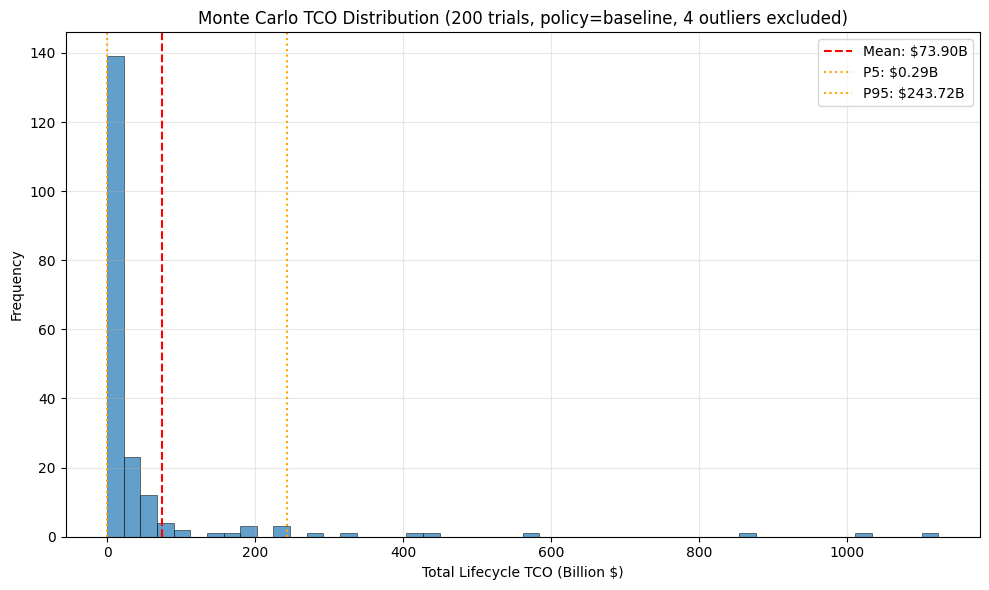

In [6]:
fig = plot_monte_carlo_distribution(mc_result)

## Multi-Policy Monte Carlo Comparison

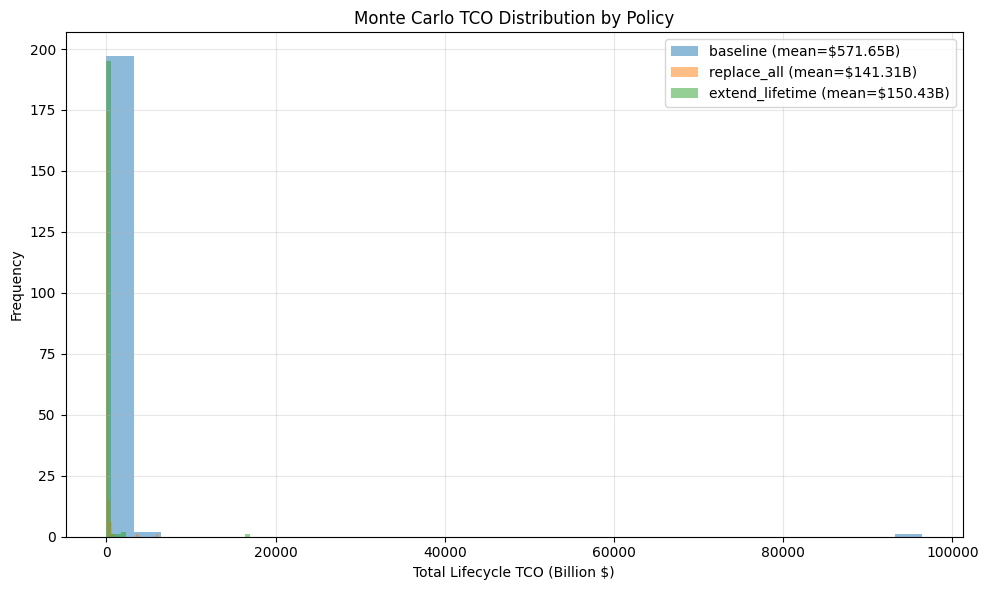

In [ ]:
mc_comparison = compare_policies_mc(
    cfg_mc,
    policy_names=['baseline', 'replace_all', 'extend_lifetime_1yr', 'extend_lifetime_2yr'],
)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
for name, mc in mc_comparison.items():
    ax.hist(mc.tco_values / 1e9, bins=30, alpha=0.5, label=f'{name} (mean=${mc.mean/1e9:.2f}B)')

ax.set_xlabel('Total Lifecycle TCO (Billion $)')
ax.set_ylabel('Frequency')
ax.set_title('Monte Carlo TCO Distribution by Policy')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()